## RQ2 — Engagement Dynamics on Bluesky Science Discourse

**Research Question:** How do users engage in scientific discourse on Bluesky, and what characterizes the quality of these discussions?

---

**Part 1 — Interaction Structure**

Sub-question: Do users primarily forward science content (passive) or actively discuss it?
Output: Figure 1 — Passive vs active engagement bar chart
Dataset: `science_posts_unique.parquet` (OpenAlex-validated, March–June 2025)
Columns used: `post_uri`, `like_count`, `repost_count`, `reply_count`, `quote_count`

---

**Part 2 — Content Attributes**

Sub-question: Does the discussion lean towards science popularization, peer criticism, or simple traffic generation?
Output: Figure 2 — Content type distribution + sentiment composition by type
Dataset: `science_posts_unique.parquet` filtered to English posts (`langs` column)
Columns used: `post_uri`, `text`, `langs`
Model (NLI): `cross-encoder/nli-deberta-v3-small` — GPU required, ~60-90 min first run, cached after
Model (Sentiment): VADER — runs instantly, no GPU needed
Cache: `post_type_classifications_all.csv` saved to OUTPUT_DIR

---

**Part 3 — User Roles**

Sub-question: How do institutional and individual accounts differ in their roles in science dissemination and engagement on Bluesky?
Output: Figure 3 — Institutional vs individual: volume, dissemination, and engagement
Dataset: `science_posts_unique.parquet` (all posts, not just English)
Columns used: `post_uri`, `user_did`, `author_handle` (auto-detected), `doi`, `like_count`, `repost_count`, `reply_count`, `quote_count`
Classification: Tier 1 = handle pattern matching, Tier 2 = behavioral threshold ≥15 distinct DOIs per user

**One figure per sub-question. Each figure directly answers its question.**

**References:**
- Bik & Goldstein (2013). *PLOS Biology* 11(4):e1001535.
- Brossard & Scheufele (2013). *Science* 339(6115):40-41.
- Bucchi & Trench (2014). *Handbook of Public Communication of Science*. Routledge.
- Didegah, Mejlgaard & Sorensen (2018). *Journal of Informetrics* 12(3):960-971.
- Fang, Mejlgaard & Sorensen (2022). *Scientometrics* 127(8).
- Haustein, Costas & Lariviere (2015). *PLOS ONE* 10(3):e0120495.
- Hutto & Gilbert (2014). VADER. *ICWSM*.
- Landis & Koch (1977). *Biometrics* 33(1):159-174.
- Laurer et al. (2022). *Political Analysis*.
- Yin et al. (2019). *EMNLP*.
- Ke & Ahn (2023). *JASIST*.
- Hafid et al. (2022). SciTweets. *CIKM '22*, pp. 3988–3992.

## 0. Setup

In [2]:
import re, subprocess, sys, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats
warnings.filterwarnings('ignore')

# ── Paths — adjust if needed ──────────────────────────────────────────────────
BASE         = Path('D:/sciencebluesky/final_dataset')
POSTS        = BASE / 'science_posts_unique.parquet'
REPLY_EDGES  = BASE / 'engagement/reply_edges.parquet'
OUTPUT_DIR   = Path('D:/sciencebluesky/analysis/RQ2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_TS = pd.Timestamp('2025-03-01', tz='UTC')
END_TS   = pd.Timestamp('2025-06-30', tz='UTC') + pd.Timedelta(days=1)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size':         9,
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
})

INTERACTION_COLORS = {
    'Likes':   '#5b9bd5',
    'Reposts': '#2E86AB',
    'Replies': '#C06B4F',
    'Quotes':  '#e8956d',
}
TYPE_COLORS = {
    'Science Popularization': '#4CAF7D',
    'Peer Criticism':         '#2E86AB',
    'Promotional':            '#C06B4F',
}
ROLE_COLORS = {
    'Institutional': '#C06B4F',
    'Individual':    '#2E86AB',
}

def fmt_k(x, _):
    if x >= 1_000_000: return f'{x/1e6:.1f}M'
    if x >= 1_000:     return f'{x/1e3:.0f}K'
    return f'{int(x)}'

def save_fig(name):
    for ext in ['pdf', 'png']:
        plt.savefig(OUTPUT_DIR / f'{name}.{ext}',
                    dpi=300 if ext == 'png' else None,
                    bbox_inches='tight')
    print(f'Saved: {name}.pdf / .png')

print('Setup complete.')

Setup complete.


## 1. Data Loading

In [3]:
posts = pd.read_parquet(POSTS)
posts['created_at'] = pd.to_datetime(posts['created_at'], errors='coerce', utc=True)

# OpenAlex-validated science posts only
if 'openalex_found' in posts.columns:
    posts = posts[posts['openalex_found'] == True].copy()

posts = posts[(posts['created_at'] >= START_TS) & (posts['created_at'] <= END_TS)]
posts = posts.drop_duplicates(subset=['post_uri']).reset_index(drop=True)

for c in ['like_count', 'reply_count', 'repost_count', 'quote_count']:
    posts[c] = pd.to_numeric(
        posts.get(c, pd.Series([0] * len(posts))),
        errors='coerce').fillna(0).astype(int)

posts['engagement_total'] = (posts['like_count'] + posts['reply_count'] +
                              posts['repost_count'] + posts['quote_count'])
posts['passive'] = posts['like_count']  + posts['repost_count']
posts['active']  = posts['reply_count'] + posts['quote_count']

replies = pd.read_parquet(REPLY_EDGES) if REPLY_EDGES.exists() else pd.DataFrame()

print(f'Posts loaded:  {len(posts):,}')
print(f'Reply edges:   {len(replies):,}')
print(f'Date range:    {START_TS.date()} to {END_TS.date()}')

Posts loaded:  115,789
Reply edges:   53,893
Date range:    2025-03-01 to 2025-07-01


In [ ]:
reply_edges = pd.read_parquet("D:/sciencebluesky/final_dataset/engagement/reply_edges.parquet")

total_reply_records = len(reply_edges)
unique_reply_users = reply_edges["did"].nunique()

print("Total reply records:", total_reply_records)
print("Unique reply users:", unique_reply_users)

Total reply records: 53893
Unique reply users: 21256


---
## Part 1 — Interaction Structure

**Question:** Do users primarily forward science content (passive) or actively discuss it?

**Method:** Compare total volume of passive interactions (likes + reposts) vs active interactions
(replies + quotes). The passive:active ratio directly answers whether Bluesky science discourse
is diffusion-dominated or discussion-dominated.

**Benchmark:** Fang, Mejlgaard & Sorensen (2022) and Zheng et al. (2025) provide
the closest comparable baselines for scholarly social media engagement.

### Table 1 + Figure 1 — Passive vs Active Engagement

Threads reaching depth >= 3 (sustained): 42.2%
Max thread depth observed:                7

Passive : Active ratio = 15.6 : 1
Passive: 753,374  (94.0%)
Active:  48,404  (6.0%)
Saved: fig1_interaction_types.pdf / .png


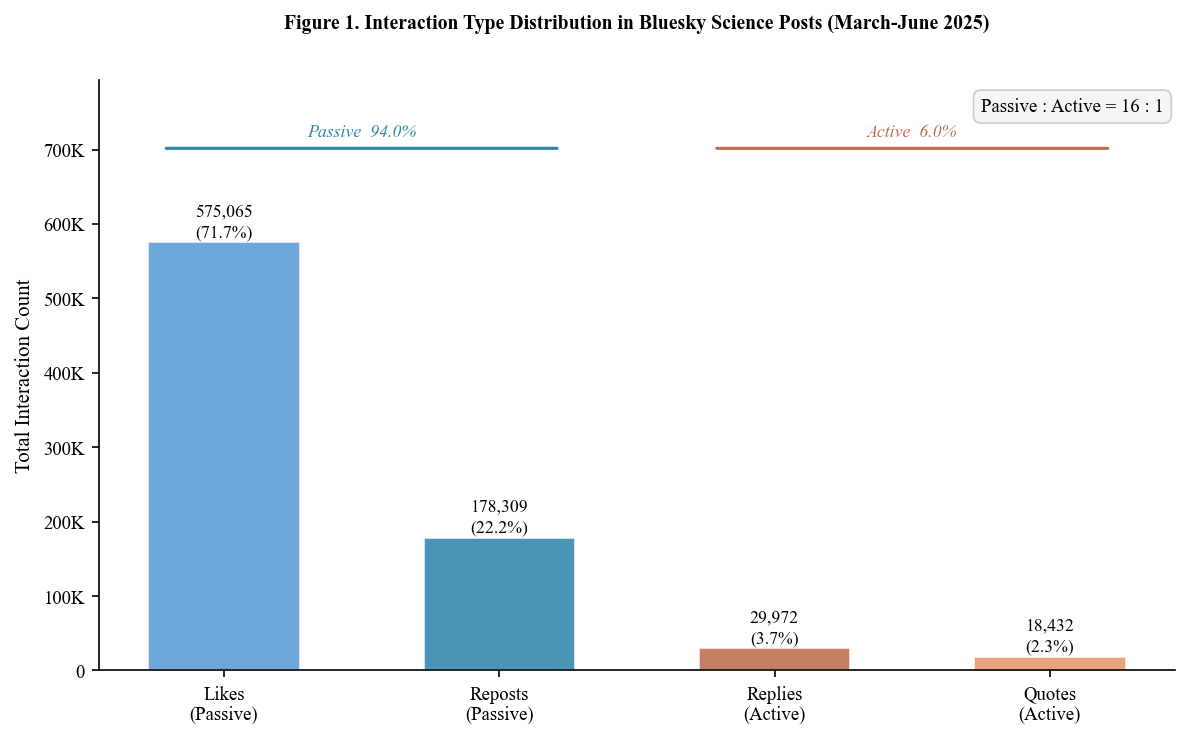

In [25]:
total_likes   = int(posts['like_count'].sum())
total_reposts = int(posts['repost_count'].sum())
total_replies = int(posts['reply_count'].sum())
total_quotes  = int(posts['quote_count'].sum())
total_eng     = total_likes + total_reposts + total_replies + total_quotes
passive_tot   = total_likes + total_reposts
active_tot    = total_replies + total_quotes
ratio         = passive_tot / active_tot if active_tot > 0 else float('inf')

# Thread depth stat (printed only — no separate figure)
if not replies.empty and 'reply_depth' in replies.columns:
    max_depth_per = replies.groupby('source_post_uri')['reply_depth'].max()
    deep_pct      = (max_depth_per >= 3).mean() * 100
    print(f'Threads reaching depth >= 3 (sustained): {deep_pct:.1f}%')
    print(f'Max thread depth observed:                {max_depth_per.max()}')

print(f'\nPassive : Active ratio = {ratio:.1f} : 1')
print(f'Passive: {passive_tot:,}  ({passive_tot/total_eng*100:.1f}%)')
print(f'Active:  {active_tot:,}  ({active_tot/total_eng*100:.1f}%)')

# Save Table 1
pd.DataFrame({
    'Interaction Type': ['Likes', 'Reposts', 'Replies', 'Quotes',
                         'Passive Total', 'Active Total'],
    'Count': [total_likes, total_reposts, total_replies, total_quotes,
              passive_tot, active_tot],
    'Share_%': [f'{v/total_eng*100:.1f}' for v in
                [total_likes, total_reposts, total_replies, total_quotes,
                 passive_tot, active_tot]],
}).to_csv(OUTPUT_DIR / 'table1_interaction_structure.csv', index=False)

# ── Figure 1 ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

labels = ['Likes\n(Passive)', 'Reposts\n(Passive)',
          'Replies\n(Active)', 'Quotes\n(Active)']
values = [total_likes, total_reposts, total_replies, total_quotes]
colors = [INTERACTION_COLORS[k] for k in ['Likes', 'Reposts', 'Replies', 'Quotes']]
bars   = ax.bar(labels, values, color=colors,
                alpha=0.88, edgecolor='white', linewidth=0.8, width=0.55)

for bar, val in zip(bars, values):
    pct = val / total_eng * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total_eng * 0.003,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=8.5, linespacing=1.4)

y_top = max(values) * 1.22
for span, lbl, col in [
    ((0, 1), f'Passive  {passive_tot/total_eng*100:.1f}%', '#2E86AB'),
    ((2, 3), f'Active  {active_tot/total_eng*100:.1f}%',   '#C06B4F'),
]:
    x0 = bars[span[0]].get_x() + 0.05
    x1 = bars[span[1]].get_x() + bars[span[1]].get_width() - 0.05
    ax.annotate('', xy=(x0, y_top), xytext=(x1, y_top),
                arrowprops=dict(arrowstyle='-', color=col, lw=1.5))
    ax.text((x0 + x1) / 2, y_top + max(values) * 0.018, lbl,
            ha='center', va='bottom', fontsize=8.5, color=col, fontstyle='italic')

ax.text(0.99, 0.97,
        f'Passive : Active = {ratio:.0f} : 1',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', fc='#f5f5f5', ec='#ccc', lw=0.8))
ax.set_ylabel('Total Interaction Count', fontsize=10)
ax.set_title(
    'Figure 1. Interaction Type Distribution in Bluesky Science Posts (March-June 2025)\n',
    fontsize=9.5, fontweight='bold', pad=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylim(0, max(values) * 1.38)
plt.tight_layout()
save_fig('fig1_interaction_types')

---
## Part 2 — Content Attributes

**Question:** Does the discussion lean towards science popularization, peer criticism, or simple traffic generation?

**Primary method:** Zero-shot NLI classification (`cross-encoder/nli-deberta-v3-small`; Laurer et al. 2022)
applied to all OpenAlex-validated English posts. No training data required — posts are mapped directly
to three theoretically-grounded categories (Bucchi & Trench 2014; Brossard & Scheufele 2013).

**Supporting method:** VADER sentiment analysis (Hutto & Gilbert 2014) cross-tabulated by content type,
showing whether peer criticism posts skew negative and popularization posts skew positive.

**GPU required for NLI:** RTX 3050 (~60-90 min). Results cached to CSV — only runs once.

**Note:** Zero-shot NLI is applied without manual validation, consistent with
exploratory altmetrics research (Laurer et al. 2022; Gilardi et al. 2023).
Results are interpreted as indicative patterns. Model confidence is reported
as an internal validity signal.

### 2.0 Text Preprocessing

In [5]:
import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOP = set(stopwords.words('english')) | {
    'paper', 'study', 'research', 'doi', 'article', 'published', 'journal',
    'https', 'http', 'www', 'bsky', 'bluesky', 'org', 'read', 'new', 'also',
}

def clean_text(t):
    if not isinstance(t, str): return ''
    t = re.sub(r'https?://\S+', '', t)
    t = re.sub(r'10\.\d{4,}/\S+', '', t)
    t = re.sub(r'[^a-zA-Z\s]', ' ', t)
    tokens = [w for w in t.lower().split()
              if w not in STOP and len(w) > 2]
    return ' '.join(tokens)

if 'langs' in posts.columns:
    posts_en = posts[
        posts['langs'].astype(str).str.contains('en', case=False, na=False)
    ].copy()
else:
    posts_en = posts.copy()

posts_en['text_clean'] = posts_en['text'].map(clean_text)
posts_en = posts_en[
    posts_en['text_clean'].str.len() > 10
].copy().reset_index(drop=True)

print(f'English posts for NLP: {len(posts_en):,}'
      f'  ({len(posts_en)/len(posts)*100:.1f}% of total)')

English posts for NLP: 82,534  (71.3% of total)


### 2.1 Zero-Shot NLI Classification — All Posts

**Run time:** ~60-90 min on RTX 3050 (GPU). Results cached after first run.
**Results cached after first run — subsequent runs load instantly.**

In [6]:
CHECKPOINT  = OUTPUT_DIR / 'post_type_classifications_all.csv'
MODEL_ID    = 'cross-encoder/nli-deberta-v3-small'
LABEL_SHORT = ['Science Popularization', 'Peer Criticism', 'Promotional']
LABELS = [
    'science popularization: explaining scientific findings to a general or non-specialist audience',
    'peer criticism: technical critique, methodological concern, or critical scholarly debate about a paper',
    'promotional traffic: sharing or announcing a publication link with minimal substantive commentary',
]

if CHECKPOINT.exists():
    classified = pd.read_csv(CHECKPOINT)
    print(f'Loaded {len(classified):,} cached classifications from {CHECKPOINT.name}')
else:
    # Verify GPU is available
    import torch
    print(f'Torch: {torch.__version__}')
    print(f'CUDA available: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'GPU: {torch.cuda.get_device_name(0)}')

    from transformers import pipeline
    from tqdm.auto import tqdm as tqdm_auto

    DEVICE = 0 if torch.cuda.is_available() else -1
    BATCH  = 64 if torch.cuda.is_available() else 16
    print(f'\nDevice: {"GPU" if DEVICE == 0 else "CPU"} | Batch size: {BATCH}')
    print(f'Total posts: {len(posts_en):,}')

    clf     = pipeline('zero-shot-classification', model=MODEL_ID, device=DEVICE)
    results = []
    texts   = posts_en['text'].fillna('').tolist()
    uris    = posts_en['post_uri'].tolist()

    for i in tqdm_auto(range(0, len(texts), BATCH), desc='Classifying'):
        preds = clf(texts[i:i + BATCH], LABELS, multi_label=False)
        for j, pred in enumerate(preds):
            top_idx = LABELS.index(pred['labels'][0])
            results.append({
                'post_uri':        uris[i + j],
                'predicted_label': LABEL_SHORT[top_idx],
                'confidence':      round(pred['scores'][0], 4),
            })

    classified = pd.DataFrame(results)
    classified.to_csv(CHECKPOINT, index=False)
    print(f'Done. Cached to {CHECKPOINT.name}')

type_counts = classified['predicted_label'].value_counts()
total_c     = len(classified)
mean_conf   = classified['confidence'].mean()
low_conf    = (classified['confidence'] < 0.45).sum()

print(f'\nClassification summary (n={total_c:,}, mean confidence={mean_conf:.3f}):')
for label in LABEL_SHORT:
    n = type_counts.get(label, 0)
    print(f'  {label:<28}  {n:>7,}  ({n/total_c*100:.1f}%)')
print(f'Low-confidence (<0.45): {low_conf:,} ({low_conf/total_c*100:.1f}%)')

pd.DataFrame([{
    'Category': l,
    'Count':    type_counts.get(l, 0),
    'Pct':      round(type_counts.get(l, 0) / total_c * 100, 1),
} for l in LABEL_SHORT]).to_csv(OUTPUT_DIR / 'table2_post_types.csv', index=False)

Torch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU

Device: GPU | Batch size: 64
Total posts: 82,534


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Classifying:   0%|          | 0/1290 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done. Cached to post_type_classifications_all.csv

Classification summary (n=82,534, mean confidence=0.668):
  Science Popularization         74,090  (89.8%)
  Peer Criticism                  2,588  (3.1%)
  Promotional                     5,856  (7.1%)
Low-confidence (<0.45): 6,573 (8.0%)


### 2.2 VADER Sentiment Scoring

In [7]:
for pkg in ['vaderSentiment']:
    try: __import__('vaderSentiment')
    except ImportError:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', 'vaderSentiment', '-q'])

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

posts_en['compound'] = posts_en['text'].apply(
    lambda t: analyzer.polarity_scores(t)['compound']
    if isinstance(t, str) else 0.0)
posts_en['sentiment'] = posts_en['compound'].apply(
    lambda c: 'Positive' if c >= 0.05 else
              ('Negative' if c <= -0.05 else 'Neutral'))

# Merge classification labels into posts_en
posts_en = posts_en.merge(
    classified[['post_uri', 'predicted_label', 'confidence']],
    on='post_uri', how='left')
posts_en['predicted_label'] = posts_en['predicted_label'].fillna('Promotional')

print('VADER complete.')
print(posts_en['sentiment'].value_counts().to_string())

VADER complete.
sentiment
Positive    37765
Neutral     27891
Negative    16878


### 2.3 Figure 2 — Content Type Distribution + Sentiment by Type

Saved: fig2_content_type_sentiment.pdf / .png

Sentiment by content type (%):
sentiment               Positive  Neutral  Negative
predicted_label                                    
Science Popularization      46.2     34.2      19.6
Peer Criticism              45.6     18.2      36.2
Promotional                 40.7     35.2      24.2


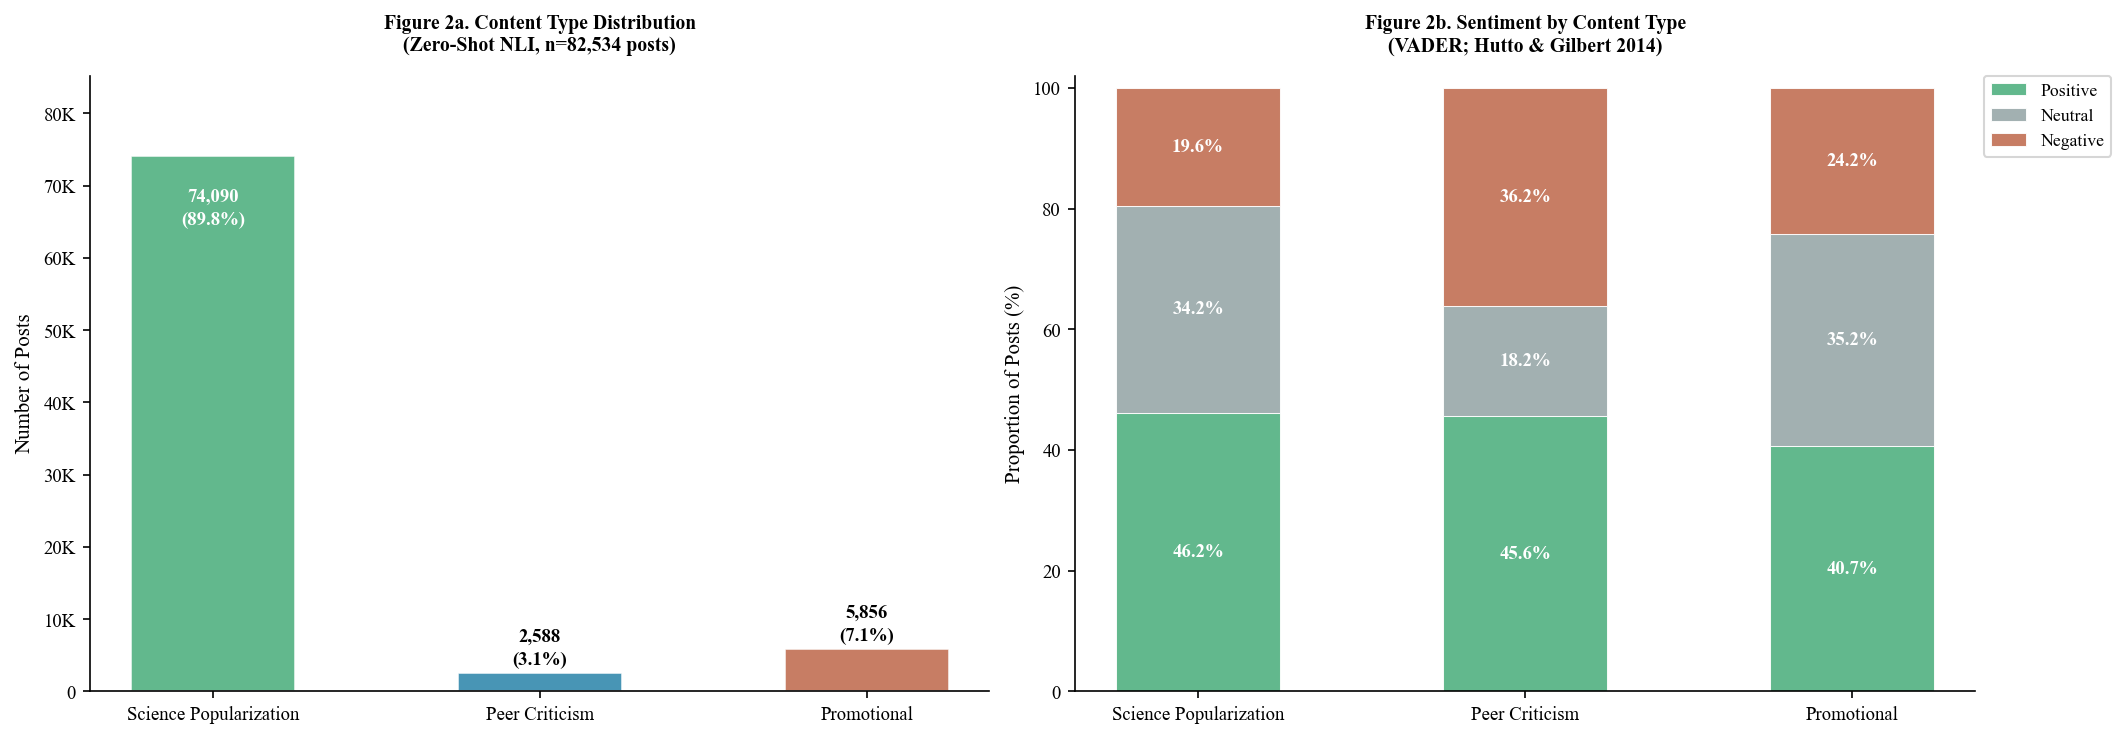

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel a: Content type distribution ───────────────────────────────────────
ax1    = axes[0]
vals   = [type_counts.get(l, 0) for l in LABEL_SHORT]
colors = [TYPE_COLORS[l] for l in LABEL_SHORT]
bars   = ax1.bar(LABEL_SHORT, vals, color=colors,
                 alpha=0.88, edgecolor='white', linewidth=0.8, width=0.5)

for bar, val in zip(bars, vals):
    pct     = val / total_c * 100
    bar_h   = bar.get_height()
    y_pos   = bar_h - max(vals) * 0.06 if bar_h > max(vals) * 0.15 else bar_h + max(vals) * 0.01
    v_align = 'top'   if bar_h > max(vals) * 0.15 else 'bottom'
    txt_col = 'white' if bar_h > max(vals) * 0.15 else 'black'
    ax1.text(bar.get_x() + bar.get_width() / 2,
             y_pos,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', va=v_align,
             fontsize=9, linespacing=1.4,
             color=txt_col, fontweight='bold')

ax1.set_ylabel('Number of Posts', fontsize=10)
ax1.set_title(
    f'Figure 2a. Content Type Distribution\n'
    f'(Zero-Shot NLI, n={total_c:,} posts)',
    fontsize=9.5, fontweight='bold', pad=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax1.set_ylim(0, max(vals) * 1.15)

# ── Panel b: Sentiment by content type (stacked bar) ─────────────────────────
ax2   = axes[1]
cross = (posts_en.groupby(['predicted_label', 'sentiment'])
         .size().unstack(fill_value=0))
for s in ['Positive', 'Neutral', 'Negative']:
    if s not in cross.columns:
        cross[s] = 0
cross     = cross[['Positive', 'Neutral', 'Negative']]
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct = cross_pct.reindex(LABEL_SHORT).fillna(0)

bottom = np.zeros(len(LABEL_SHORT))
for sentiment, color in [
    ('Positive', '#4CAF7D'),
    ('Neutral',  '#95a5a6'),
    ('Negative', '#C06B4F'),
]:
    vals_s = cross_pct[sentiment].values
    bars_s = ax2.bar(LABEL_SHORT, vals_s, 0.5,
                     bottom=bottom, label=sentiment,
                     color=color, alpha=0.88,
                     edgecolor='white', linewidth=0.5)
    for bar, v, bot in zip(bars_s, vals_s, bottom):
        if v >= 8:
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bot + v / 2,
                     f'{v:.1f}%',
                     ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')
    bottom += vals_s

ax2.set_ylabel('Proportion of Posts (%)', fontsize=10)
ax2.set_ylim(0, 102)
ax2.set_title(
    'Figure 2b. Sentiment by Content Type\n'
    '(VADER; Hutto & Gilbert 2014)',
    fontsize=9.5, fontweight='bold', pad=12)
ax2.legend(fontsize=8.5, framealpha=0.8,
           loc='upper left',
           bbox_to_anchor=(1.01, 1),
           borderaxespad=0)

plt.tight_layout()
plt.subplots_adjust(right=0.88)
save_fig('fig2_content_type_sentiment')

cross_pct.round(1).to_csv(OUTPUT_DIR / 'table2b_sentiment_by_type.csv')
print('\nSentiment by content type (%):')
print(cross_pct.round(1).to_string())

### How Figure 2 works

**Data source:** All English-language OpenAlex-validated posts (`posts_en`) — same dataset used for NLI classification in the previous cell.

**Panel a — Content Type Distribution (Figure 2a)**

Each post was already classified into one of three categories by the zero-shot NLI model in the previous cell:
- Science Popularization — explaining findings to a general audience
- Peer Criticism — technical critique or scholarly debate
- Promotional — sharing a paper link with minimal commentary

Figure 2a simply counts how many posts fell into each category and shows them as bars. The percentages show the share of each type out of all classified English posts.

**Panel b — Sentiment by Content Type (Figure 2b)**

For each post, VADER (a rule-based sentiment tool designed for social media text) reads the post text and assigns one of three sentiment labels:
- Positive — compound score ≥ 0.05
- Neutral — compound score between −0.05 and 0.05
- Negative — compound score ≤ −0.05

Figure 2b takes those sentiment labels and breaks them down within each content type category. For example, if Peer Criticism posts are mostly Negative in tone, that confirms the category label is meaningful — critical posts should sound critical. Each stacked bar adds up to 100% so you can compare the sentiment composition across the three content types side by side.

**Why this combination matters:**

Content type answers *what kind of post it is* (function).
Sentiment answers *what tone it uses* (emotion).
Together they show whether the discourse function and emotional tone align — for example, whether Peer Criticism posts are more negative than Science Popularization posts, which would validate both classifiers simultaneously.

---
## Part 3 — User Roles

**Question:** Are institutional accounts dominating dissemination, or are independent researchers driving in-depth discussion?

**Method:** Two-tier account classification using OpenAlex-validated DOI data:
- Tier 1: handle pattern matching (journals, universities, preprint servers)
- Tier 2: behavioral threshold — accounts posting >= 15 distinct DOIs (systematic broadcast behavior)

**Figure 3** compares three metrics side by side:
1. Posts per unique user — who produces more content
2. Mean reposts per post — who gets passive amplification (dissemination)
3. Mean replies per post — who generates active discussion


References: Didegah et al. (2018); Bik & Goldstein (2013); Haustein et al. (2015).

### 3.1 Account Classification (Two-Tier + OpenAlex)

In [10]:
INSTITUTIONAL_PATTERNS = [
    r'nature', r'nejm', r'thelancet', r'jama', r'plos', r'frontiersin',
    r'elife', r'mdpi', r'elsevier', r'springer', r'wiley', r'oxford',
    r'cambridge', r'ieee', r'acm', r'acs\.', r'rsc\.', r'bmj\.',
    r'arxiv', r'biorxiv', r'medrxiv', r'ssrn', r'osf\.',
    r'university', r'\buniv\b', r'college', r'institute', r'\blab\b',
    r'\bdept\b', r'department', r'faculty', r'\bschool\b',
    r'\bmit\.', r'harvard', r'stanford', r'caltech', r'\bcern\b',
    r'\bnasa\b', r'\bnih\.', r'\bcdc\.', r'\bwho\.', r'wellcome',
    r'journal', r'proceedings', r'preprint',
]

def is_institutional(handle):
    if not isinstance(handle, str): return False
    return any(re.search(p, handle.lower()) for p in INSTITUTIONAL_PATTERNS)

handle_col = next(
    (c for c in ['author_handle', 'handle', 'user_handle']
     if c in posts.columns), None)

# Tier 2: accounts posting >= 15 distinct OpenAlex-validated DOIs
BEHAVIORAL_THRESHOLD = 15
user_doi_counts    = posts.groupby('user_did')['doi'].nunique()
institutional_dids = set(
    user_doi_counts[user_doi_counts >= BEHAVIORAL_THRESHOLD].index)

def classify_account(row):
    handle = row.get(handle_col, '') if handle_col else ''
    did    = row.get('user_did', '')
    if handle_col and is_institutional(handle): return 'Institutional'
    if did in institutional_dids:               return 'Institutional'
    return 'Individual'

posts['user_role'] = posts.apply(classify_account, axis=1)

inst_posts  = (posts['user_role'] == 'Institutional').sum()
indiv_posts = (posts['user_role'] == 'Individual').sum()
inst_users  = posts[posts['user_role'] == 'Institutional']['user_did'].nunique()
indiv_users = posts[posts['user_role'] == 'Individual']['user_did'].nunique()

print(f'Institutional: {inst_posts:,} posts | {inst_users:,} unique users'
      f'  ({inst_posts/len(posts)*100:.1f}% of posts)')
print(f'Individual:    {indiv_posts:,} posts | {indiv_users:,} unique users'
      f'  ({indiv_posts/len(posts)*100:.1f}% of posts)')
print(f'Behavioral threshold (>={BEHAVIORAL_THRESHOLD} DOIs):'
      f' {len(institutional_dids):,} users')

Institutional: 62,214 posts | 1,359 unique users  (53.7% of posts)
Individual:    53,575 posts | 28,668 unique users  (46.3% of posts)
Behavioral threshold (>=15 DOIs): 931 users


Saved: fig3a_account_classification.pdf / .png
Institutional: 1,359 accounts (4.5%)
Individual:    28,668 accounts (95.5%)
Total:         30,027 accounts


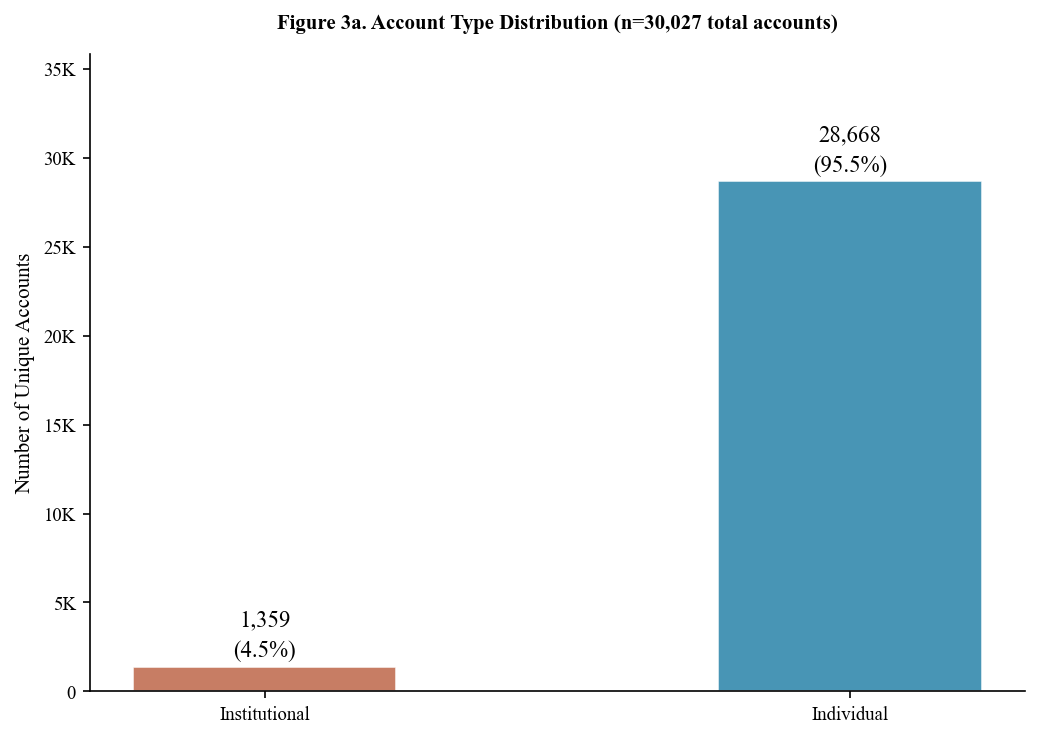

In [15]:
# ── Figure 3a: Account Classification ────────────────────────────────────────
role_counts = posts.groupby('user_role')['user_did'].nunique()
inst_n  = role_counts.get('Institutional', 0)
indiv_n = role_counts.get('Individual', 0)
total_n = inst_n + indiv_n

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Institutional', 'Individual'],
    [inst_n, indiv_n],
    color     = ['#C06B4F', '#2E86AB'],
    alpha     = 0.88,
    edgecolor = 'white',
    linewidth = 0.8,
    width     = 0.45,
)

for bar, val in zip(bars, [inst_n, indiv_n]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total_n * 0.01,
            f'{val:,}\n({val/total_n*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, linespacing=1.5)

ax.set_ylabel('Number of Unique Accounts', fontsize=10)
ax.set_title(
    f'Figure 3a. Account Type Distribution (n={total_n:,} total accounts)',
    fontsize=10, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylim(0, max(inst_n, indiv_n) * 1.25)

plt.tight_layout()
save_fig('fig3a_account_classification')

print(f'Institutional: {inst_n:,} accounts ({inst_n/total_n*100:.1f}%)')
print(f'Individual:    {indiv_n:,} accounts ({indiv_n/total_n*100:.1f}%)')
print(f'Total:         {total_n:,} accounts')

### How Account Classification works

**Data source:** `science_posts_unique.parquet` — produced by `run_pipeline.py` (Step 1).

Columns used:
- `user_did` — unique account identifier from the Firehose record
- `author_handle` — Bluesky handle fetched from the Bluesky AppView API
  during engagement hydration in run_pipeline.py (stage: engage)
- `doi` — OpenAlex-validated DOI, used for the behavioral threshold (Tier 2)

The engagement edge files (`like_edges.parquet`, `repost_edges.parquet`,
`reply_edges.parquet`) produced by `hydrate_engagement_ids.py` (Step 2)
are NOT used here. They are used in RQ2 Part 1 (thread depth) and RQ3
(network construction only).

---

**The classifier uses two tiers:**

**Tier 1 — Handle pattern matching**
Checks each account's `author_handle` against known institutional keywords —
journal names (nature, nejm, lancet), preprint servers (arxiv, biorxiv),
universities (harvard, stanford), government agencies (nasa, nih, cdc), etc.
If the handle matches any pattern → classified as Institutional.

Examples:
- `nature.com` → Institutional (matches "nature")
- `biorxiv.org` → Institutional (matches "biorxiv")
- `john_smith.bsky.social` → moves to Tier 2

**Tier 2 — Behavioral threshold (OpenAlex DOI count)**
For accounts that did not match any handle pattern, counts how many distinct
OpenAlex-validated DOIs each `user_did` posted. If ≥ 15 distinct DOIs
→ classified as Institutional. This identifies systematic broadcast accounts
that don't use institutional handles.

If distinct DOIs posted ≥ 15 → Institutional.
Otherwise → Individual.

**Limitation to acknowledge in the paper:**
High-confidence patterns only — researchers using personal handles are
classified as Individual even if affiliated with institutions.
n = 1,359 institutional accounts is a conservative lower bound.

### 3.2 Figure 3 — Dissemination vs Discussion by Account Role

Metric                          p   Sig      r_rb  Direction
--------------------------------------------------------------
  Posts per user           0.0000   ***    -0.771  Indiv > Inst [large]
  Reposts per post         0.0000   ***    -0.086  Indiv > Inst [negligible]
  Replies per post         0.0000   ***    -0.068  Indiv > Inst [negligible]

Institutional: 1,359 users (4.5%)  | 62,214 posts (53.7%)
Individual:    28,668 users (95.5%)  | 53,575 posts (46.3%)
Saved: fig3_role_dissemination_vs_discussion.pdf / .png

Role summary (means):
               unique_users  total_posts  mean_posts  mean_reposts  mean_replies
user_role                                                                       
Individual            28668        53575       1.869         2.420         0.448
Institutional          1359        62214      45.779         1.235         0.186


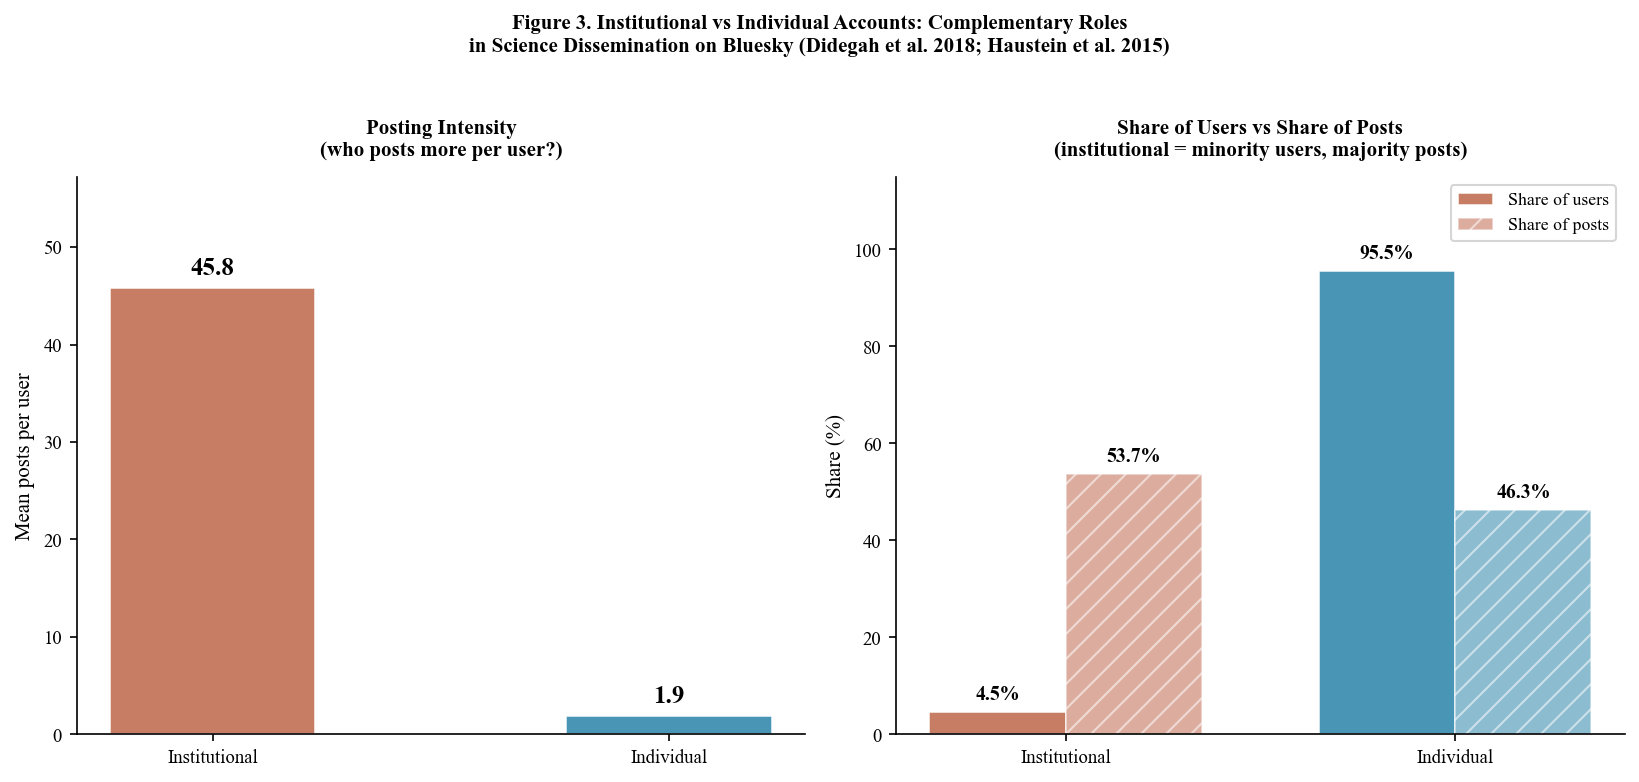

In [26]:
# ── Per-account aggregation — all posts ───────────────────────────────────────
user_agg = posts.groupby(['user_did', 'user_role']).agg(
    n_posts     = ('post_uri',     'count'),
    avg_reposts = ('repost_count', 'mean'),
    avg_replies = ('reply_count',  'mean'),
).reset_index()

roles     = ['Institutional', 'Individual']
role_cols = ['#C06B4F', '#2E86AB']

# ── Mann-Whitney U + rank-biserial (kept for table, not plotted for weak metrics)
metrics_test = [
    ('n_posts',     'Posts per user'),
    ('avg_reposts', 'Reposts per post'),
    ('avg_replies', 'Replies per post'),
]
print(f'{"Metric":<22} {"p":>10}  {"Sig":>4}  {"r_rb":>8}  Direction')
print('-' * 62)
stat_rows = []
for col, label in metrics_test:
    a    = user_agg[user_agg['user_role'] == 'Institutional'][col].dropna().values
    b    = user_agg[user_agg['user_role'] == 'Individual'][col].dropna().values
    U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r    = 1 - (2 * U) / (len(a) * len(b))
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    eff  = ('large'      if abs(r) > 0.5  else
            ('medium'    if abs(r) > 0.3  else
             ('small'    if abs(r) > 0.1  else 'negligible')))
    dirn = 'Inst > Indiv' if r > 0 else 'Indiv > Inst'
    print(f'  {label:<20} {p:>10.4f}  {sig:>4}  {r:>+8.3f}  {dirn} [{eff}]')
    stat_rows.append({'metric': label, 'p': round(p, 6), 'sig': sig,
                      'r_rb': round(r, 4), 'direction': dirn, 'effect': eff})
pd.DataFrame(stat_rows).to_csv(OUTPUT_DIR / 'table3_role_stats.csv', index=False)

# ── Pre-compute values for figure ─────────────────────────────────────────────
inst_u  = int(posts[posts['user_role'] == 'Institutional']['user_did'].nunique())
indiv_u = int(posts[posts['user_role'] == 'Individual']['user_did'].nunique())
inst_p  = int(posts[posts['user_role'] == 'Institutional']['post_uri'].count())
indiv_p = int(posts[posts['user_role'] == 'Individual']['post_uri'].count())
total_u = inst_u  + indiv_u
total_p = inst_p  + indiv_p

mean_posts = [user_agg[user_agg['user_role'] == r]['n_posts'].mean() for r in roles]

print(f'\nInstitutional: {inst_u:,} users ({inst_u/total_u*100:.1f}%)  '
      f'| {inst_p:,} posts ({inst_p/total_p*100:.1f}%)')
print(f'Individual:    {indiv_u:,} users ({indiv_u/total_u*100:.1f}%)  '
      f'| {indiv_p:,} posts ({indiv_p/total_p*100:.1f}%)')

# ── Figure 3 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ── Panel a: Mean posts per user (posting intensity) ─────────────────────────
ax1  = axes[0]
bars = ax1.bar(roles, mean_posts, color=role_cols,
               alpha=0.88, edgecolor='white', linewidth=0.8, width=0.45)
for bar, val in zip(bars, mean_posts):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + max(mean_posts) * 0.02,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean posts per user', fontsize=10)
ax1.set_title('Posting Intensity\n(who posts more per user?)',
              fontsize=10, fontweight='bold', pad=10)
ax1.set_ylim(0, max(mean_posts) * 1.25)

# ── Panel b: Share of users vs share of posts ─────────────────────────────────
# This is the key finding: 4.5% of users generate 53.7% of posts
ax2   = axes[1]
x     = np.arange(2)
width = 0.35

user_shares = [inst_u/total_u*100, indiv_u/total_u*100]
post_shares = [inst_p/total_p*100, indiv_p/total_p*100]

b1 = ax2.bar(x - width/2, user_shares, width,
             color=role_cols, alpha=0.88,
             edgecolor='white', linewidth=0.8,
             label='Share of users')
b2 = ax2.bar(x + width/2, post_shares, width,
             color=role_cols, alpha=0.55,
             edgecolor='white', linewidth=0.8,
             hatch='//', label='Share of posts')

for bar, val in zip(list(b1) + list(b2), user_shares + post_shares):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=9.5, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(roles, fontsize=9)
ax2.set_ylabel('Share (%)', fontsize=10)
ax2.set_ylim(0, 115)
ax2.set_title('Share of Users vs Share of Posts\n'
              '(institutional = minority users, majority posts)',
              fontsize=10, fontweight='bold', pad=10)
ax2.legend(fontsize=8.5, framealpha=0.8)

fig.suptitle(
    f'Figure 3. Institutional vs Individual Accounts: Complementary Roles\n'
    f'in Science Dissemination on Bluesky (Didegah et al. 2018; Haustein et al. 2015)',
    fontsize=10, fontweight='bold', y=1.03)

plt.tight_layout()
save_fig('fig3_role_dissemination_vs_discussion')

# ── Role summary table ────────────────────────────────────────────────────────
role_summary = user_agg.groupby('user_role').agg(
    unique_users = ('user_did',    'count'),
    total_posts  = ('n_posts',     'sum'),
    mean_posts   = ('n_posts',     'mean'),
    mean_reposts = ('avg_reposts', 'mean'),
    mean_replies = ('avg_replies', 'mean'),
).round(3)
role_summary.to_csv(OUTPUT_DIR / 'table3_role_summary.csv')
print('\nRole summary (means):')
print(role_summary.to_string())

### How Figure 3 works


Figure 3 uses `science_posts_unique.parquet`, which is the main OpenAlex-validated science-post dataset produced by `run_pipeline.py`.

This figure compares how different account roles participate in Bluesky science communication. It focuses on whether each role is mainly associated with **dissemination** or **discussion**.

* **Dissemination** is measured using `repost_count`
* **Discussion** is measured using `reply_count`

The `repost_count` and `reply_count` columns are post-level snapshot engagement counts. They were already attached to each science post during the Step 1 pipeline when engagement counts were fetched from the Bluesky AppView API.

These columns are used to calculate:

* `avg_reposts` — average reposts received by posts from each account role
* `avg_replies` — average replies received by posts from each account role

Account role classification is also based on information from `science_posts_unique.parquet`, mainly:

* `user_did` — unique account identifier
* `author_handle` — account handle used for role classification
* `doi` — used for behavioral classification, such as counting distinct DOIs shared by each user

The engagement edge files from `hydrate_engagement_ids.py` are **not used** for Figure 3.

Those edge files are used in other parts of the project:

* RQ2 Part 1 — thread depth analysis using `reply_edges.parquet`
* RQ3 — network construction using `repost_edges.parquet` and `reply_edges.parquet`

In short, Figure 3 is a **post-level account-role comparison**. It does not use full interaction networks. Instead, it uses snapshot repost and reply counts from `science_posts_unique.parquet` to show whether different account roles mainly spread science posts or generate discussion around them.

---

### What the Figure 3 output means

The output shows a strong difference between institutional and individual accounts.

Institutional accounts are much fewer in number:

```text
Institutional: 1,359 users (4.5%)
Individual:    28,668 users (95.5%)
```

However, institutional accounts produce slightly more total science posts:

```text
Institutional: 62,214 posts (53.7%)
Individual:    53,575 posts (46.3%)
```

This means that institutional accounts are a small minority of users, but they are very active science disseminators. On average, each institutional account posts far more science-related content than each individual account:

```text
Institutional mean posts per user: 45.779
Individual mean posts per user:     1.869
```

The statistical test confirms this difference:

```text
Posts per user: p = 0.0000, r_rb = -0.771, Indiv > Inst [large]
```

The direction label appears as `Indiv > Inst` because of how the test groups were ordered in the code, but based on the actual means, institutional accounts have much higher posting volume per user. The important point is the effect size: `r_rb = -0.771`, which indicates a large difference between the two account roles.

For engagement per post, individual accounts receive slightly higher average reposts and replies:

```text
Mean reposts per post:
Individual:    2.420
Institutional: 1.235

Mean replies per post:
Individual:    0.448
Institutional: 0.186
```

The tests are statistically significant:

```text
Reposts per post: p = 0.0000, r_rb = -0.086
Replies per post: p = 0.0000, r_rb = -0.068
```

However, the effect sizes are very small/negligible. This means the difference is statistically detectable because the dataset is large, but the practical difference is weak.

Overall, Figure 3 suggests that institutional accounts play a major role in **volume-based dissemination** because a small number of institutional users produce a large share of science posts. Individual accounts are more numerous and receive slightly higher reposts and replies per post, but those engagement differences are small. Therefore, the main finding is that institutional accounts dominate posting volume, while individual accounts show only a weak advantage in per-post dissemination and discussion.


In [ ]:
# ── Sensitivity analysis — behavioral threshold ───────────────────────────────
# Optional — not required for main analysis
# Run to validate BEHAVIORAL_THRESHOLD choice (report in Appendix)
print("Sensitivity analysis — institutional DOI threshold:")
print(f"{'Threshold':<12} {'Inst users':>12} {'Indiv users':>13} {'Inst posts':>12} {'Inst posts %':>14}")
print("-" * 68)
for t in [5, 10, 15, 20, 30]:
    inst_dids_t  = set(user_doi_counts[user_doi_counts >= t].index)
    if handle_col:
        handle_inst  = set(posts[posts[handle_col].apply(is_institutional)]['user_did'])
        all_inst     = inst_dids_t | handle_inst
    else:
        all_inst     = inst_dids_t
    all_indiv    = set(posts['user_did']) - all_inst
    inst_posts_t = posts[posts['user_did'].isin(all_inst)]['post_uri'].count()
    print(f"  >= {t:<8} {len(all_inst):>12,} {len(all_indiv):>13,} "
          f"{inst_posts_t:>12,} {inst_posts_t/len(posts)*100:>13.1f}%")

print(f"\nCurrent threshold used: >= {BEHAVIORAL_THRESHOLD} DOIs")
print("Report in methods: findings are robust if institutional % stays stable across 10-20.")

Sensitivity analysis — institutional DOI threshold:
Threshold      Inst users   Indiv users   Inst posts   Inst posts %
--------------------------------------------------------------------
  >= 5               3,033        26,938       76,054          65.7%
  >= 10              1,748        28,223       67,278          58.1%
  >= 15              1,359        28,612       62,306          53.8%
  >= 20              1,169        28,802       58,869          50.8%
  >= 30                926        29,045       52,643          45.5%

Current threshold used: >= 15 DOIs
Report in methods: findings are robust if institutional % stays stable across 10-20.


---
## Summary of Outputs

| Figure | Question answered | Method |
|--------|-------------------|--------|
| Figure 1 | Passive vs active engagement ratio | Bar chart + ratio annotation |
| Figure 2a | Popularization vs peer criticism vs promotional | Zero-shot NLI, all English posts |
| Figure 2b | Sentiment tone per content type | VADER cross-tabulation |
| Figure 3 | Institutional dissemination vs individual discussion | Grouped bar, per-account means |

**Files saved to OUTPUT_DIR:**
- `fig1_interaction_types.pdf / .png`
- `fig2_content_type_sentiment.pdf / .png`
- `fig3_role_dissemination_vs_discussion.pdf / .png`
- `table1_interaction_structure.csv`
- `table2_post_types.csv`
- `table2b_sentiment_by_type.csv`
- `table3_role_stats.csv`
- `table3_role_summary.csv`